# Text Classification using NLP (BoW & TF-IDF)

## Objective
This project implements a complete NLP pipeline including:
- Text preprocessing
- Feature extraction using Bag of Words and TF-IDF
- Model training and evaluation

## Technologies Used
- Python
- Pandas
- Scikit-learn
- NLTK

## Dataset
Brief description of dataset (Spam/Ham or the one you used).

In [7]:
!pip install pandas scikit-learn nltk

**Data Loading**

Load the dataset and check its structure.

In [8]:
import pandas as pd

# Replace the example URL with your dataset's raw URL
df = pd.read_csv('/content/labeled_data.csv')

# Display the first few rows of the DataFrame
print(df.head())

   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't...  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...  


Data Exploration
Check dataset shape and missing values.

In [9]:
print("Shape:", df.shape)

Shape: (24783, 7)


Data Cleaning

In [10]:
print(df.isnull().sum())

Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64


**Bag of Words (BoW)**

In [11]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Text Preprocessing
Steps performed:
- Convert text to lowercase
- Remove punctuation
- Remove stopwords
- Clean unwanted characters

In [12]:
def clean_text(text):
  text=text.lower()
  text=re.sub(r"http\S+", "", text)
  text=re.sub(r"www.\S+", "", text)
  text=re.sub(r"[^\w\s]", "", text)
  text=re.sub(r"\d+", "", text)
  words=text.split()
  words=[w for w in words if w not in stop_words]
  text=" ".join(words)
  return text

In [13]:
df['clean_text'] = df['tweet'].apply(clean_text)
print("Original:", df['tweet'][0])
print("Cleaned:", df['clean_text'][0])


Original: !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
Cleaned: rt mayasolovely woman shouldnt complain cleaning house amp man always take trash


Feature Extraction using Bag of Words (BoW)

Convert text into numerical form using word frequency.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()
X_bow=bow.fit_transform(df['clean_text'])
print("BOW Shape:", X_bow.shape)
print("Vocabulary Size:", len(bow.vocabulary_))

BOW Shape: (24783, 33447)
Vocabulary Size: 33447


Feature Extraction using TF-IDF
TF-IDF gives importance to meaningful words instead of frequent ones.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_tfidf=tfidf.fit_transform(df['clean_text'])
print("TF-IDF Shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

TF-IDF Shape: (24783, 33447)
Vocabulary size: 33447


Model Training
Train machine learning models on extracted features.

In [16]:
from sklearn.model_selection import train_test_split
y=df['class']
X_train_bow, X_test_bow, y_train_bow, y_test_bow=train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)
X_train_tfidf, X_test_tfidf, _, _=train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

**Naive Bayes**

In [17]:
from sklearn.naive_bayes import MultinomialNB
nb_bow=MultinomialNB()
nb_bow.fit(X_train_bow, y_train_bow)
nb_tfidf=MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train_bow)

MultinomialNB()

**Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression

lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train_bow)

LogisticRegression(max_iter=1000)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predictions
pred_nb_bow = nb_bow.predict(X_test_bow)
pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

Model Evaluation
Evaluate model performance using:
- Accuracy
- Precision
- Recall
- F1-score

In [20]:
print("Naive Bayes (BoW)")
print(classification_report(y_test_bow, pred_nb_bow))

print("Naive Bayes (TF-IDF)")
print(classification_report(y_test_bow, pred_nb_tfidf))

print("Logistic Regression (TF-IDF)")
print(classification_report(y_test_bow, pred_lr_tfidf))

Naive Bayes (BoW)
              precision    recall  f1-score   support

           0       0.42      0.10      0.17       290
           1       0.88      0.97      0.92      3832
           2       0.84      0.64      0.73       835

    accuracy                           0.87      4957
   macro avg       0.71      0.57      0.61      4957
weighted avg       0.84      0.87      0.85      4957

Naive Bayes (TF-IDF)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       290
           1       0.79      1.00      0.88      3832
           2       0.94      0.14      0.24       835

    accuracy                           0.80      4957
   macro avg       0.58      0.38      0.37      4957
weighted avg       0.77      0.80      0.72      4957

Logistic Regression (TF-IDF)
              precision    recall  f1-score   support

           0       0.55      0.12      0.20       290
           1       0.90      0.97      0.93      3832
       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Confusion Matrix**

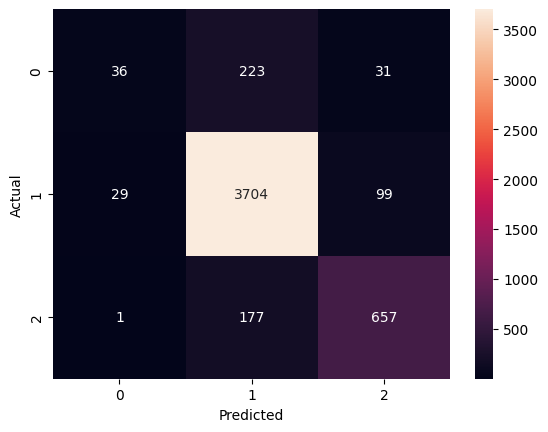

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_bow, pred_lr_tfidf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Results Comparison

| Feature | Model               | Accuracy | Precision | Recall | F1 |
| ------- | ------------------- | -------- | --------- | ------ | -- |
| BoW     | Naive Bayes         |    0.87      |   0.84        |    0.87    |   0.85 |
| TF-IDF  | Naive Bayes         |   0.80       |       0.77    |      0.80  |  0.72  |
| TF-IDF  | Logistic Regression |       0.89   |   0.87        | 0.89       | 0.87   |


 Conclusion

TF-IDF generally performs better because it considers word importance rather than only frequency.

Conclusion: Abusive Language Detection using NLP

This lab focused on building a text classification pipeline to detect abusive language using classical Natural Language Processing (NLP) techniques. The dataset was first inspected to understand its structure, class distribution, and presence of missing values. It was observed that the dataset was imbalanced, with one class having significantly more samples than the others. Therefore, weighted evaluation metrics were considered for fair performance measurement.

Text preprocessing was performed to clean and standardize the data. The preprocessing steps included converting text to lowercase, removing punctuation and URLs, eliminating stopwords, and tokenizing the text. These steps helped reduce noise and improve the quality of input for machine learning models.

For feature extraction, two common techniques were used:

Bag of Words (BoW) – represents text based on word frequency.

TF-IDF (Term Frequency–Inverse Document Frequency) – assigns importance weights to words based on their relevance.

These techniques converted textual data into numerical form so that machine learning models could process it.

Two classification algorithms were trained:

Multinomial Naive Bayes

Logistic Regression

The dataset was split into 80% training and 20% testing to evaluate model performance on unseen data.

The results showed:

Method	Accuracy
BoW + Naive Bayes	0.87
TF-IDF + Naive Bayes	0.80
TF-IDF + Logistic Regression	0.89

Weighted Precision, Recall, and F1-score were also analyzed due to class imbalance. Among all models, TF-IDF with Logistic Regression achieved the best overall performance, with high accuracy and balanced evaluation metrics.

It was also observed that:

Logistic Regression handled feature importance better than Naive Bayes.

TF-IDF did not perform well with Naive Bayes in this dataset.

Class imbalance affected predictions for minority classes.

Overall, this lab demonstrated the importance of text preprocessing, feature engineering, and proper model evaluation in NLP tasks. Classical machine learning techniques such as TF-IDF and Logistic Regression can effectively detect abusive language with good accuracy. This workflow can be further improved using balanced datasets, advanced preprocessing, or deep learning models.